In [15]:
!pip install onnx onnxruntime

Fatal Python error: init_import_site: Failed to import the site module
Python runtime state: initialized
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 980, in exec_module
  File "<frozen site>", line 626, in <module>
  File "<frozen site>", line 609, in main
  File "<frozen site>", line 541, in venv
  File "<frozen site>", line 394, in addsitepackages
  File "<frozen site>", line 236, in addsitedir
  File "<frozen site>", line 188, in addpackage
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0

In [9]:
# ==========================================
# CELL 1: المكتبات الأساسية ودوال الذكاء العنيف (MixUp & Focal Loss)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
import os
import json

# 1. إعداد كارت الشاشة
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Training on: {DEVICE}")

# 2. دالة Focal Loss (لحل مشكلة الأماكن الصعبة)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

# 3. دوال الـ MixUp (للتدريب العنيف ودمج الصور)
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

🔥 Training on: cuda


In [10]:
# ==========================================
# CELL 2: فلترة الكلاسات الضعيفة وتقسيم الداتا (Train/Val)
# ==========================================
DATA_DIR = r"N:\gradution project\Final_Balanced_Dataset" 
BATCH_SIZE = 16 
MIN_IMAGES_PER_CLASS = 25 # تجاهل أي مكان صوره أقل من 25 لمنع الحفظ

# كلاس مخصص لتجاهل الفولدرات الضعيفة من غير مسحها من الهارد
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
        if not classes:
            raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")
        
        valid_classes = []
        ignored_classes = []
        
        for class_name in classes:
            class_dir = os.path.join(directory, class_name)
            num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
            
            if num_images >= MIN_IMAGES_PER_CLASS:
                valid_classes.append(class_name)
            else:
                ignored_classes.append((class_name, num_images))
        
        if ignored_classes:
            print(f"⚠️ تم تجاهل {len(ignored_classes)} مكان عشان صورهم أقل من {MIN_IMAGES_PER_CLASS}:")
            for c, n in ignored_classes:
                print(f"   - {c} ({n} صور)")
                
        class_to_idx = {cls_name: i for i, cls_name in enumerate(valid_classes)}
        return valid_classes, class_to_idx

# التعديلات (التقطيع العشوائي للتدريب فقط)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("\n🔍 جاري فحص الداتا...")
full_train_dataset = FilteredImageFolder(DATA_DIR, transform=train_transforms)
full_val_dataset = FilteredImageFolder(DATA_DIR, transform=val_transforms)

# التقسيم 80/20
dataset_size = len(full_train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=generator).tolist()

train_dataset = Subset(full_train_dataset, indices[:train_size])
val_dataset = Subset(full_val_dataset, indices[train_size:])

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print("-" * 30)
print(f"✅ Classes Approved (>= 25 images): {NUM_CLASSES}")
print(f"📦 Training Images: {dataset_sizes['train']} | Validation Images: {dataset_sizes['val']}")


🔍 جاري فحص الداتا...
⚠️ تم تجاهل 8 مكان عشان صورهم أقل من 25:
   - Al-Manyal_Palace_Museum (22 صور)
   - Corniche_(Alexandria) (24 صور)
   - Madrasah_of_Al-Nasir_Muhammad (21 صور)
   - Mosque_of_al-Maridani (23 صور)
   - Qasr_Qarun (21 صور)
   - Theban_Necropolis (20 صور)
   - Tomb_of_Nakht_TT52 (20 صور)
   - White_Monastery (21 صور)
⚠️ تم تجاهل 8 مكان عشان صورهم أقل من 25:
   - Al-Manyal_Palace_Museum (22 صور)
   - Corniche_(Alexandria) (24 صور)
   - Madrasah_of_Al-Nasir_Muhammad (21 صور)
   - Mosque_of_al-Maridani (23 صور)
   - Qasr_Qarun (21 صور)
   - Theban_Necropolis (20 صور)
   - Tomb_of_Nakht_TT52 (20 صور)
   - White_Monastery (21 صور)
------------------------------
✅ Classes Approved (>= 25 images): 105
📦 Training Images: 13706 | Validation Images: 3427


In [11]:
# ==========================================
# CELL 3: معمارية الموديل (EfficientNet-B3 + Dropout)
# ==========================================
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, NUM_CLASSES)
)
model = model.to(DEVICE)

EPOCHS = 40
criterion = FocalLoss(gamma=2.0) 
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6) 

BEST_MODEL_PATH = "fasa7ny_ultimate_model.pth"
print("🛠️ Model Architecture and Optimizers are ready!")

🛠️ Model Architecture and Optimizers are ready!


In [12]:
# ==========================================
# CELL 4: وحش التدريب (The Training Loop) - النسخة النهائية المضمونة
# ==========================================
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("🚀 Starting Ultimate Training...")
since = time.time()

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('=' * 20)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0
        total_batches = len(dataloaders[phase])

        for i, (inputs, labels) in enumerate(dataloaders[phase]):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                if phase == 'train':
                    inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha=0.2)
                    outputs = model(inputs)
                    loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
                    _, preds = torch.max(outputs, 1)
                    # في الـ Mixup بنحسب الدقة على الـ targets الأصلية عشان نكون أدق
                    running_corrects += (lam * torch.sum(preds == targets_a.data) + (1 - lam) * torch.sum(preds == targets_b.data))
                else:
                    outputs = model(inputs)
                    loss = criterion(outputs, labels) 
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
                 
            # 🟢 شريط التحميل اليدوي
            progress = (i + 1) / total_batches
            bar_length = 30
            filled = int(bar_length * progress)
            bar = '█' * filled + '-' * (bar_length - filled)
            print(f'\r{phase.capitalize()} Phase: [{bar}] {int(progress * 100)}% ({i+1}/{total_batches} Batches)', end='', flush=True)

        print() # سطر جديد بعد الـ 100%

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = float(running_corrects) / dataset_sizes[phase]
        
        # حفظ النتائج (بدون .item() عشان ده float عادي)
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc) 

        print(f'>> {phase.capitalize()} Result - Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print("🌟 Best Model Saved!")

time_elapsed = time.time() - since
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'🏆 Best Validation Accuracy: {best_acc:.4f}')

model.load_state_dict(best_model_wts)

🚀 Starting Ultimate Training...

Epoch 1/40
Train Phase: [██████████████████████████████] 100% (857/857 Batches)
>> Train Result - Loss: 2.2209 | Acc: 0.4475
Val Phase: [██████████████████████████████] 100% (215/215 Batches)
>> Val Result - Loss: 0.9026 | Acc: 0.7085
🌟 Best Model Saved!

Epoch 2/40
Train Phase: [██████████████████████████████] 100% (857/857 Batches)
>> Train Result - Loss: 1.4992 | Acc: 0.6048
Val Phase: [██████████████████████████████] 100% (215/215 Batches)
>> Val Result - Loss: 0.7839 | Acc: 0.7488
🌟 Best Model Saved!

Epoch 3/40
Train Phase: [██████████████████████████████] 100% (857/857 Batches)
>> Train Result - Loss: 1.2474 | Acc: 0.6713
Val Phase: [██████████████████████████████] 100% (215/215 Batches)
>> Val Result - Loss: 0.6302 | Acc: 0.7820
🌟 Best Model Saved!

Epoch 4/40
Train Phase: [██████████████████████████████] 100% (857/857 Batches)
>> Train Result - Loss: 1.1374 | Acc: 0.7026
Val Phase: [██████████████████████████████] 100% (215/215 Batches)
>> Val 

<All keys matched successfully>

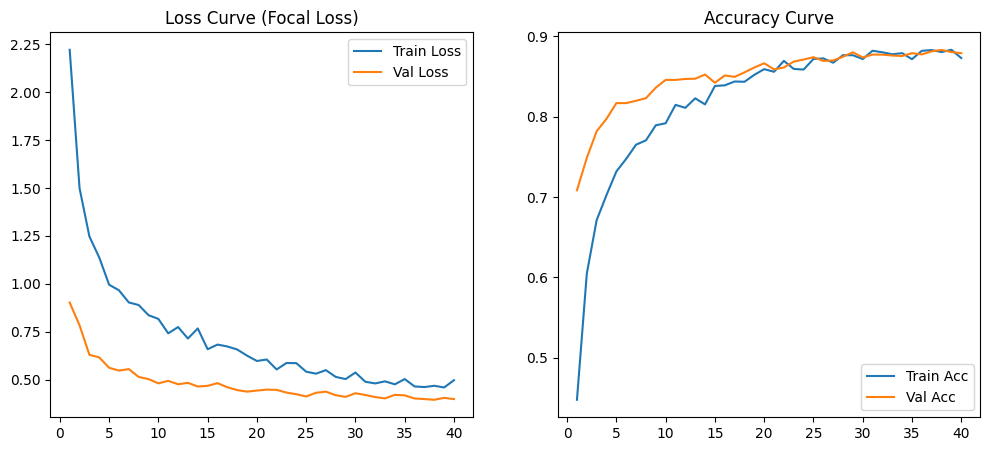

In [13]:
# ==========================================
# CELL 5: رسم النتائج (للـ Documentation)
# ==========================================
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Focal Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

In [ ]:
# ==========================================
# CELL 6: تجهيز ملفات الباك إند لتوماس أوتوماتيكياً
# ==========================================
print("⚙️ جاري إنشاء ملفات الباك إند لتوماس...")

# 1. إنشاء classes.json (هياخد الكلاسات المفلترة فقط)
with open("classes.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False)

# 2. إنشاء requirements.txt
reqs = "torch\ntorchvision\nPillow\n"
with open("requirements.txt", "w") as f:
    f.write(reqs)

# 3. إنشاء inference.py (متوافق مع B3 والـ Dropout الجديد)
inference_code = """import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json

DEVICE = torch.device("cpu")

with open("classes.json", "r", encoding="utf-8") as f:
    CLASSES = json.load(f)

NUM_CLASSES = len(CLASSES)

model = models.efficientnet_b3(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, NUM_CLASSES)
)

MODEL_PATH = "fasa7ny_ultimate_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
    place_name = CLASSES[predicted_idx.item()]
    conf_percentage = round(confidence.item() * 100, 2)
    return place_name, conf_percentage

if __name__ == "__main__":
    pass
"""
with open("inference.py", "w", encoding="utf-8") as f:
    f.write(inference_code)

print("✅ تم استخراج الملفات بنجاح!")
print("💡 ابعت (classes.json, requirements.txt, inference.py, fasa7ny_ultimate_model.pth) لتوماس.")

⚙️ جاري إنشاء ملفات الباك إند لتوماس...
✅ تم استخراج الملفات بنجاح!
💡 ابعت (classes.json, requirements.txt, inference.py, fasa7ny_ultimate_model.pth) لتوماس.
